# ID5059: Group Project

- The business outcome is to **reduce passenger waiting times** while **avoiding an excess of idle drivers**. You must present something *actionable* to the Operations Manager

- Your primary task is to build predictive models for **ride demand** for the Manhattan area. These
predictions should support recommendations **about driver deployment over time and space**.
You should also model **fare-related quantities** (such as average fare or total revenue per hour)
in order to explore which locations and times are likely to be most profitable for drivers.

- For example, you could predict a typical week, or a typical
week in each season (if you see a large fluctuation between summer and winter for example).

## Preamble

In [1]:
import pandas as pd 
import numpy as np
import datetime as dt
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Data cleaning/ Split

### Load in Raw Data

In [2]:
# Load in Raw data - Monthly data for 2024 (memory-efficient)
warnings.filterwarnings('ignore')

dtype_map = {
    'VendorID':              'Int8',
    'passenger_count':       'Int8',
    'trip_distance':         'float32',
    'RatecodeID':            'float32',
    'store_and_fwd_flag':    'str',
    'PULocationID':          'Int16',
    'DOLocationID':          'Int16',
    'payment_type':          'Int8',
    'fare_amount':           'float32',
    'extra':                 'float32',
    'mta_tax':               'float32',
    'tip_amount':            'float32',
    'tolls_amount':          'float32',
    'improvement_surcharge': 'float32',
    'total_amount':          'float32',
    'congestion_surcharge':  'float32',
    'Airport_fee':           'float32',
}

chunks = []
for m in range(1, 13):
    path = f'Raw Data/nyc_taxi_2024-{m:02d}.csv'
    df = pd.read_csv(path, dtype=dtype_map)
    chunks.append(df)
    print(f"Loaded {path}: {len(df):,} rows")
    del df  # free each monthly frame immediately

nyc_taxi_2024_Raw = pd.concat(chunks, ignore_index=True)
del chunks
print(f"\nTotal rows loaded: {len(nyc_taxi_2024_Raw):,}")

Loaded Raw Data/nyc_taxi_2024-01.csv: 2,964,624 rows
Loaded Raw Data/nyc_taxi_2024-02.csv: 3,007,526 rows
Loaded Raw Data/nyc_taxi_2024-03.csv: 3,582,628 rows
Loaded Raw Data/nyc_taxi_2024-04.csv: 3,514,289 rows
Loaded Raw Data/nyc_taxi_2024-05.csv: 3,723,833 rows
Loaded Raw Data/nyc_taxi_2024-06.csv: 3,539,193 rows
Loaded Raw Data/nyc_taxi_2024-07.csv: 3,076,903 rows
Loaded Raw Data/nyc_taxi_2024-08.csv: 2,979,183 rows
Loaded Raw Data/nyc_taxi_2024-09.csv: 3,633,030 rows
Loaded Raw Data/nyc_taxi_2024-10.csv: 3,833,771 rows
Loaded Raw Data/nyc_taxi_2024-11.csv: 3,646,369 rows
Loaded Raw Data/nyc_taxi_2024-12.csv: 3,668,371 rows

Total rows loaded: 41,169,720


In [3]:
nyc_taxi_2024 = nyc_taxi_2024_Raw.copy()

### Data cleaning/Aggregation and Features

In [4]:
# Load TLC zone lookup to identify Manhattan zones reproducibly.
zones = pd.read_csv('Raw Data/taxi_zone_lookup.csv')

manhattan_zones = set(zones.loc[zones['Borough'] == 'Manhattan', 'LocationID'])
print(f"Manhattan zones loaded: {len(manhattan_zones)} zones")

# Parse datetimes (stored as strings in raw CSVs)
nyc_taxi_2024['tpep_pickup_datetime']  = pd.to_datetime(nyc_taxi_2024['tpep_pickup_datetime'])
nyc_taxi_2024['tpep_dropoff_datetime'] = pd.to_datetime(nyc_taxi_2024['tpep_dropoff_datetime'])

# Fix mixed-type store_and_fwd_flag (Y/N strings with NaN in some months)
nyc_taxi_2024['store_and_fwd_flag'] = (
    nyc_taxi_2024['store_and_fwd_flag']
    .astype(str).str.upper()
    .map({'Y': True, 'N': False})
)

# congestion_surcharge and Airport_fee are absent for some vendor records, not truly missing
nyc_taxi_2024['congestion_surcharge'] = nyc_taxi_2024['congestion_surcharge'].fillna(0)
nyc_taxi_2024['Airport_fee']          = nyc_taxi_2024['Airport_fee'].fillna(0)

# Naively Drop invalid and voided records.
# Note: payment_type=0 rows are always the same rows as null passenger_count and
# null RatecodeID (Vendor 2 records with missing metadata), so the payment_type
# filter is sufficient to remove all of them, but each condition is kept explicit.
# RatecodeID=99 is a separate invalid code (not in the TLC data dictionary) and
# is filtered independently.
n0 = len(nyc_taxi_2024)

valid = (
    (nyc_taxi_2024['fare_amount']    >  0)  &  # negative = void/correction
    (nyc_taxi_2024['total_amount']   >  0)  &
    (nyc_taxi_2024['trip_distance']  >  0)  &  # zero-distance ghost trips
    (nyc_taxi_2024['passenger_count'] > 0)  &  # NaN rows also excluded by > 0
    (nyc_taxi_2024['payment_type']   != 0)  &  # 0 = vendor metadata missing
    (~nyc_taxi_2024['RatecodeID'].isin([99, np.nan])) &  # 99 = invalid/unknown rate
    (nyc_taxi_2024['tpep_dropoff_datetime'] > nyc_taxi_2024['tpep_pickup_datetime'])
)
nyc_taxi_2024 = nyc_taxi_2024[valid]

# Compute trip duration, then drop implausible trips
nyc_taxi_2024['trip_duration_min'] = (
    (nyc_taxi_2024['tpep_dropoff_datetime'] - nyc_taxi_2024['tpep_pickup_datetime'])
    .dt.total_seconds() / 60
)

nyc_taxi_2024 = nyc_taxi_2024[
    (nyc_taxi_2024['trip_distance']    <= 100) &  # >100 miles implausible in NYC
    (nyc_taxi_2024['fare_amount']      <= 100) &  # extreme fare outliers
    (nyc_taxi_2024['trip_duration_min'].between(1, 300))  # <1 min or >5 hrs
]

print(f"Dropped {n0 - len(nyc_taxi_2024):,} invalid/outlier rows "
        f"({(n0 - len(nyc_taxi_2024)) / n0:.1%} of total)")

# Filter to Manhattan pickups only
n1 = len(nyc_taxi_2024)
nyc_taxi_2024 = nyc_taxi_2024[nyc_taxi_2024['PULocationID'].isin(manhattan_zones)]
print(f"Dropped {n1 - len(nyc_taxi_2024):,} non-Manhattan rows "
        f"({(n1 - len(nyc_taxi_2024)) / n1:.1%} of post-cleaning total)")

# Temporal features at trip level
nyc_taxi_2024['pickup_hour']  = nyc_taxi_2024['tpep_pickup_datetime'].dt.hour
nyc_taxi_2024['pickup_dow']   = nyc_taxi_2024['tpep_pickup_datetime'].dt.dayofweek  # 0=Mon
nyc_taxi_2024['pickup_month'] = nyc_taxi_2024['tpep_pickup_datetime'].dt.month
nyc_taxi_2024['pickup_date']  = nyc_taxi_2024['tpep_pickup_datetime'].dt.normalize()
nyc_taxi_2024['season']       = nyc_taxi_2024['pickup_month'].map(
    {12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
)
nyc_taxi_2024['is_weekend']   = nyc_taxi_2024['pickup_dow'].isin([5, 6])
nyc_taxi_2024['is_rush_hour'] = nyc_taxi_2024['pickup_hour'].isin([7, 8, 9, 16, 17, 18, 19])

# Aggregate to hourly zone-level demand table.
# trip_count and total_revenue are the two model targets.
# avg_fare and avg_duration are kept as descriptive summaries for EDA only.
# Trip-level stats unknowable at forecast time (e.g. fare_per_mile, tip_rate)
# are excluded as they cannot be used as inputs when predicting future demand.
nyc_taxi_2024_aggregated = (
    nyc_taxi_2024
    .groupby(['PULocationID', 'pickup_date', 'pickup_hour'])
    .agg(
        trip_count       = ('VendorID',         'count'),  # TARGET: demand
        total_revenue    = ('total_amount',      'sum'),   # TARGET: revenue
        avg_fare         = ('fare_amount',       'mean'),  # EDA only
        avg_duration_min = ('trip_duration_min', 'mean'),  # EDA only
    )
    .reset_index()
)

# Re-attach time features (all deterministic from date + hour, so no groupby ambiguity)
nyc_taxi_2024_aggregated['pickup_dow']   = nyc_taxi_2024_aggregated['pickup_date'].dt.dayofweek
nyc_taxi_2024_aggregated['pickup_month'] = nyc_taxi_2024_aggregated['pickup_date'].dt.month
nyc_taxi_2024_aggregated['season']       = nyc_taxi_2024_aggregated['pickup_month'].map(
    {12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
)
nyc_taxi_2024_aggregated['is_weekend']   = nyc_taxi_2024_aggregated['pickup_dow'].isin([5, 6])
nyc_taxi_2024_aggregated['is_rush_hour'] = nyc_taxi_2024_aggregated['pickup_hour'].isin([7, 8, 9, 16, 17, 18, 19])

nyc_taxi_2024_aggregated = nyc_taxi_2024_aggregated.sort_values(['PULocationID', 'pickup_date', 'pickup_hour']).reset_index(drop=True)

# Lag and rolling features for both targets.
# A pivot (hour × zone) is reindexed to a gapless hourly DatetimeIndex before
# shifting, so each shift() step is an exact time interval regardless of missing
# zone-hours in the aggregation. Zero-trip hours are filled with 0 in the pivot
# but no extra rows are added to demand. Only the original aggregated rows are kept.
nyc_taxi_2024_aggregated['pickup_datetime'] = (
    nyc_taxi_2024_aggregated['pickup_date'] + pd.to_timedelta(nyc_taxi_2024_aggregated['pickup_hour'], unit='h')
)


Manhattan zones loaded: 69 zones
Dropped 6,234,406 invalid/outlier rows (15.1% of total)
Dropped 3,533,865 non-Manhattan rows (10.1% of post-cleaning total)


### Train/Test Split

In [5]:
# Split dataset into train/test sets
# First 3 weeks (days 1-21) of each month - train
# Last week (days 22+) of each month - test

taxi_clean_train = nyc_taxi_2024_aggregated[nyc_taxi_2024_aggregated['pickup_date'].dt.day <= 21].copy()
taxi_clean_test  = nyc_taxi_2024_aggregated[nyc_taxi_2024_aggregated['pickup_date'].dt.day  > 21].copy()

### Feature Engineering

In [ ]:
# Feature engineering

def feature_engineering(taxidata):

    full_dt_idx = pd.date_range(
        start=taxidata['pickup_datetime'].min(),
        end=taxidata['pickup_datetime'].max(),
        freq='h'
    )
    lookup_idx = pd.MultiIndex.from_arrays(
        [taxidata['pickup_datetime'], taxidata['PULocationID']]
    )

    for target, prefix in [('trip_count', 'demand'), ('total_revenue', 'revenue')]:
        pivot = (
            taxidata.pivot_table(
                index='pickup_datetime', columns='PULocationID',
                values=target, aggfunc='sum'
            )
            .reindex(full_dt_idx, fill_value=0)
        )
        taxidata[f'{prefix}_lag_1h']   = pivot.shift(1).stack().reindex(lookup_idx).values
        taxidata[f'{prefix}_lag_24h']  = pivot.shift(24).stack().reindex(lookup_idx).values
        taxidata[f'{prefix}_lag_1w']   = pivot.shift(168).stack().reindex(lookup_idx).values
        taxidata[f'{prefix}_roll_24h'] = (
            pivot.shift(1).rolling(24, min_periods=12).mean()
            .stack().reindex(lookup_idx).values
        )
        
    # Cyclical encoding of hour
    taxidata['hour_sin'] = np.sin(2 * np.pi * taxidata['pickup_hour'] / 24)
    taxidata['hour_cos'] = np.cos(2 * np.pi * taxidata['pickup_hour'] / 24)

    # Hour x weekend interaction
    taxidata['hour_x_weekend'] = taxidata['pickup_hour'] * taxidata['is_weekend'].astype(int)


    taxidata = taxidata.drop(columns='pickup_datetime')
    # drop rows with any missing lag features (e.g. first 24h of data, or zones with sparse demand)
    # only about 2% of rows
    taxidata = taxidata.dropna(subset= [col for col in taxidata.columns if 'lag' in col])

    # Convert to Data Wrangler-compatible types (DW cannot serialise datetime64 or bool)
    taxidata['pickup_date']  = taxidata['pickup_date'].astype(str)
    taxidata['is_weekend']   = taxidata['is_weekend'].astype(int)
    taxidata['is_rush_hour'] = taxidata['is_rush_hour'].astype(int)

    print(f"\nFinal demand table: {taxidata.shape[0]:,} rows x {taxidata.shape[1]} columns")
    print(f"Targets: trip_count (demand), total_revenue (revenue)")

    taxidata_cleaned = taxidata.copy()

    return taxidata_cleaned


In [8]:
# Add features into the training set

taxi_clean = feature_engineering(taxi_clean_train)


Final demand table: 311,348 rows x 20 columns
Targets: trip_count (demand), total_revenue (revenue)


### Data Dictionary : Cleaned Demand Table (`taxi_clean`)

Each row represents **one pickup zone × one hour** combination.  
Only Manhattan pickup zones are included (69 TLC zones).

---

### Identifiers / Time Index

| Column | Type | Description |
|---|---|---|
| `PULocationID` | int | TLC taxi zone ID for the pickup location. Maps to the `taxi_zone_lookup.csv` reference table. |
| `pickup_date` | str (YYYY-MM-DD) | Calendar date of the pickup hour. |
| `pickup_hour` | int (0–23) | Hour of day (24-hour clock) for the pickup window. |

---

### Target Variables

| Column | Type | Description |
|---|---|---|
| `trip_count` | int | **Primary target.** Total number of trips that started in this zone during this hour. Measures ride demand. |
| `total_revenue` | float | **Secondary target.** Sum of `total_amount` (USD) across all trips in this zone-hour. Measures revenue potential. |

---

### Descriptive Summaries *(EDA only! do not use as model features)*

| Column | Type | Description |
|---|---|---|
| `avg_fare` | float | Mean base fare (`fare_amount`) in USD for trips in this zone-hour. Excludes surcharges and tips. |
| `avg_duration_min` | float | Mean trip duration in minutes for trips in this zone-hour. |

---

### Temporal Features

| Column | Type | Description |
|---|---|---|
| `pickup_dow` | int (0–6) | Day of the week: 0 = Monday, 6 = Sunday. |
| `pickup_month` | int (1–12) | Calendar month of the pickup. |
| `season` | str | Season derived from month: `Winter` (Dec–Feb), `Spring` (Mar–May), `Summer` (Jun–Aug), `Autumn` (Sep–Nov). |
| `is_weekend` | int (0/1) | 1 if the pickup falls on Saturday or Sunday, 0 otherwise. |
| `is_rush_hour` | int (0/1) | 1 if the pickup hour is in the AM rush (07:00–09:00) or PM rush (16:00–19:00), 0 otherwise. |

---

### Lag & Rolling Features: Demand (`trip_count`)

| Column | Type | Description |
|---|---|---|
| `demand_lag_1h` | float | `trip_count` for the **same zone, 1 hour earlier**. Captures short-term momentum. |
| `demand_lag_24h` | float | `trip_count` for the **same zone, 24 hours earlier**. Captures same-hour-yesterday demand. |
| `demand_lag_1w` | float | `trip_count` for the **same zone, 168 hours (1 week) earlier**. Captures weekly seasonality. |
| `demand_roll_24h` | float | Rolling 24-hour **mean** of `trip_count` for the same zone, computed over the 24 hours *before* the current hour (no data leakage). |

---

### Lag & Rolling Features: Revenue (`total_revenue`)

| Column | Type | Description |
|---|---|---|
| `revenue_lag_1h` | float | `total_revenue` for the **same zone, 1 hour earlier**. |
| `revenue_lag_24h` | float | `total_revenue` for the **same zone, 24 hours earlier**. |
| `revenue_lag_1w` | float | `total_revenue` for the **same zone, 168 hours (1 week) earlier**. |
| `revenue_roll_24h` | float | Rolling 24-hour **mean** of `total_revenue` for the same zone, computed over the 24 hours before the current hour. |

---

> **Note on NaN values:** Lag and rolling columns will be `NaN` for the first hours of the dataset (insufficient history). These rows should be dropped or imputed before model training.


## General Exploratory Data Analysis

Understanding the data better.

In [9]:
taxi_clean.shape

(311348, 20)

In [10]:
taxi_clean.columns

Index(['PULocationID', 'pickup_date', 'pickup_hour', 'trip_count',
       'total_revenue', 'avg_fare', 'avg_duration_min', 'pickup_dow',
       'pickup_month', 'season', 'is_weekend', 'is_rush_hour', 'demand_lag_1h',
       'demand_lag_24h', 'demand_lag_1w', 'demand_roll_24h', 'revenue_lag_1h',
       'revenue_lag_24h', 'revenue_lag_1w', 'revenue_roll_24h'],
      dtype='object')

In [11]:
taxi_clean.dtypes

PULocationID          Int16
pickup_date          object
pickup_hour           int32
trip_count            Int64
total_revenue       float32
avg_fare            float32
avg_duration_min    float64
pickup_dow            int32
pickup_month          int32
season               object
is_weekend            int64
is_rush_hour          int64
demand_lag_1h         Int64
demand_lag_24h        Int64
demand_lag_1w         Int64
demand_roll_24h     float64
revenue_lag_1h      float32
revenue_lag_24h     float32
revenue_lag_1w      float32
revenue_roll_24h    float64
dtype: object

In [12]:
# pickup_date should be datetime so converting from str to datetime
taxi_clean['pickup_date'] = pd.to_datetime(taxi_clean['pickup_date'])

In [13]:
# checking time continuity for pickup date
taxi_clean['pickup_date'].min(), taxi_clean['pickup_date'].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-03-02 00:00:00'))

In [14]:
# check zone imbalance
taxi_clean['PULocationID'].value_counts().head()

PULocationID
48     6047
186    6047
68     6045
100    6044
79     6043
Name: count, dtype: Int64

In [15]:
# checking missing values
taxi_clean.isna().sum()

PULocationID          0
pickup_date           0
pickup_hour           0
trip_count            0
total_revenue         0
avg_fare              0
avg_duration_min      0
pickup_dow            0
pickup_month          0
season                0
is_weekend            0
is_rush_hour          0
demand_lag_1h         0
demand_lag_24h        0
demand_lag_1w         0
demand_roll_24h     821
revenue_lag_1h        0
revenue_lag_24h       0
revenue_lag_1w        0
revenue_roll_24h    821
dtype: int64

In [16]:
lag_roll_cols = [col for col in taxi_clean.columns if ('lag' in col) or ('roll' in col)]
taxi_clean = taxi_clean.dropna(subset=lag_roll_cols)

In [17]:
taxi_clean.isna().sum()

PULocationID        0
pickup_date         0
pickup_hour         0
trip_count          0
total_revenue       0
avg_fare            0
avg_duration_min    0
pickup_dow          0
pickup_month        0
season              0
is_weekend          0
is_rush_hour        0
demand_lag_1h       0
demand_lag_24h      0
demand_lag_1w       0
demand_roll_24h     0
revenue_lag_1h      0
revenue_lag_24h     0
revenue_lag_1w      0
revenue_roll_24h    0
dtype: int64

In [18]:
taxi_clean.describe()

,PULocationID,pickup_date,pickup_hour,trip_count,total_revenue,avg_fare,avg_duration_min,pickup_dow,pickup_month,is_weekend,is_rush_hour,demand_lag_1h,demand_lag_24h,demand_lag_1w,demand_roll_24h,revenue_lag_1h,revenue_lag_24h,revenue_lag_1w,revenue_roll_24h
count,310527.0,310527,310527.000000,310527.0,310527.000000,310527.000000,310527.000000,310527.000000,310527.000000,310527.000000,310527.000000,310527.0,310527.0,310527.0,310527.000000,310527.000000,310527.000000,310527.000000,310527.000000
mean,151.905515,2024-06-26 21:07:50.463438336,12.176332,70.847221,1676.150391,16.711088,13.830339,3.052330,6.519514,0.295701,0.312417,70.679174,67.369977,46.904559,67.561989,1672.640991,1594.246216,1108.165161,1598.808749
min,4.0,2024-01-01 00:00:00,0.000000,1.0,1.010000,0.010000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,90.0,2024-04-01 00:00:00,7.000000,11.0,273.705002,13.366666,10.927944,1.000000,4.000000,0.000000,0.000000,11.0,8.0,0.0,21.737986,269.649994,211.349998,0.000000,546.114739
50%,151.0,2024-07-01 00:00:00,12.000000,40.0,961.440002,15.283333,13.151282,3.000000,7.000000,0.000000,0.000000,40.0,36.0,11.0,56.304348,957.320007,863.510010,269.399994,1300.313332
75%,230.0,2024-10-01 00:00:00,18.000000,103.0,2354.609985,18.250000,16.018205,5.000000,10.000000,1.000000,1.000000,103.0,98.0,66.0,99.125000,2351.585083,2255.880005,1524.214966,2281.065418
max,263.0,2025-03-02 00:00:00,23.000000,996.0,21620.949219,100.000000,263.266667,6.000000,12.000000,1.000000,1.000000,996.0,996.0,996.0,359.375000,21620.949219,21620.949219,21620.949219,8412.274158
std,72.364265,NaN,6.759003,83.140927,1975.409424,6.163425,4.568134,2.001476,3.441726,0.456358,0.463480,83.175966,82.601747,75.308661,56.594725,1975.848877,1962.397949,1785.871826,1343.580164


In [19]:
# check non unique values
taxi_clean.nunique()

PULocationID            63
pickup_date            254
pickup_hour             24
trip_count             658
total_revenue       208028
avg_fare            142257
avg_duration_min    225721
pickup_dow               7
pickup_month            12
season                   4
is_weekend               2
is_rush_hour             2
demand_lag_1h          659
demand_lag_24h         658
demand_lag_1w          640
demand_roll_24h      17309
revenue_lag_1h      207650
revenue_lag_24h     200361
revenue_lag_1w      152438
revenue_roll_24h    309788
dtype: int64

In [20]:
# check duplicates
taxi_clean.duplicated().sum()

np.int64(0)

In [21]:
# checking feature scales
taxi_clean.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
PULocationID,151.905515,72.364265,4.0,263.0
pickup_date,2024-06-26 21:07:50.463438336,NaN,2024-01-01 00:00:00,2025-03-02 00:00:00
pickup_hour,12.176332,6.759003,0.0,23.0
trip_count,70.847221,83.140927,1.0,996.0
total_revenue,1676.150391,1975.409424,1.01,21620.949219
avg_fare,16.711088,6.163425,0.01,100.0
avg_duration_min,13.830339,4.568134,1.0,263.266667
pickup_dow,3.05233,2.001476,0.0,6.0
pickup_month,6.519514,3.441726,1.0,12.0
is_weekend,0.295701,0.456358,0.0,1.0


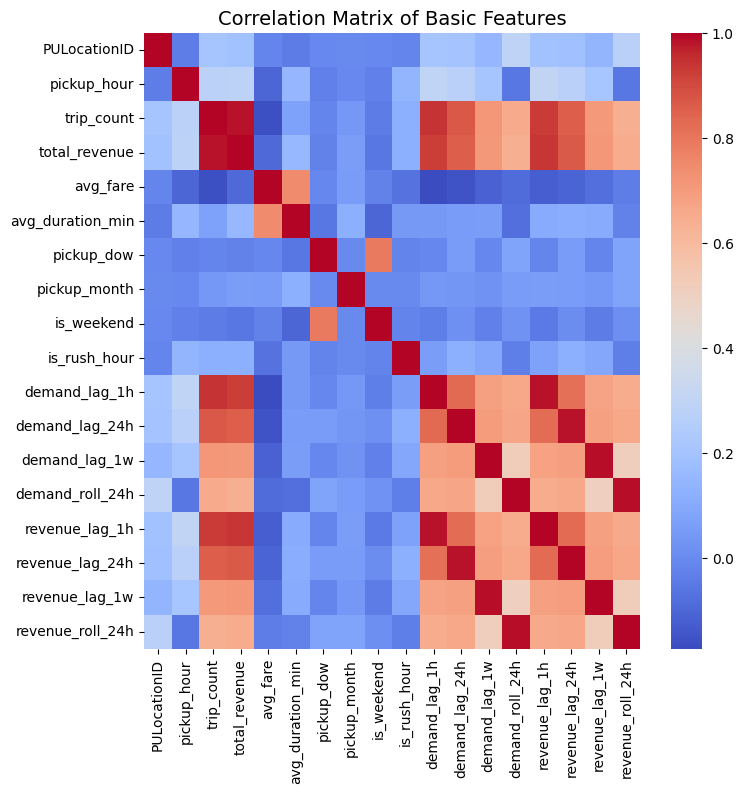

In [22]:
# checking correlation between features
corr = taxi_clean.corr(numeric_only=True)

plt.figure(figsize=(8, 8))
sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Matrix of Basic Features", fontsize=14)
plt.show()

## Exploratory Data Analysis : Predicting Demand

Understanding the data better.

In [23]:
# general function to use for the chosen target variable, plotting relationships between target and other features

def eda_target(df, target_variable):
    print(f"\nEDA for target variable: {target_variable}\n")

    # plotting distribution of the target variable
    plt.figure(figsize=(6, 4))
    plt.hist(df[target_variable], bins=50)
    plt.title(f"Distribution of {target_variable}")
    plt.xlabel(target_variable)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # plotting target variable against numeric features
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != target_variable]

    if numeric_cols:
        n_cols = 3
        n_rows = math.ceil(len(numeric_cols) / n_cols)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

        for i, col in enumerate(numeric_cols):
            ax = axes[i]
            sns.scatterplot(
                x=df[col],
                y=df[target_variable],
                alpha=0.1,
                s=10,
                ax=ax
            )
            ax.set_title(f"{target_variable} vs {col}")
            ax.set_xlabel(col)
            ax.set_ylabel(target_variable)

        for j in range(len(numeric_cols), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    # plotting target variable against categorical features
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    extra_cat_cols = ['PULocationID', 'pickup_hour', 'pickup_dow', 'pickup_month', 'season']
    cat_cols += [col for col in extra_cat_cols if col in df.columns]

    cat_cols = list(set(cat_cols))
    cat_cols = [col for col in cat_cols if col != target_variable]

    if cat_cols:
        n_cols = 3
        n_rows = math.ceil(len(cat_cols) / n_cols)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

        day_map = {
            0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu',
            4: 'Fri', 5: 'Sat', 6: 'Sun'
        }

        month_map = {
            1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
            5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
            9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
        }

        for i, col in enumerate(cat_cols):
            ax = axes[i]
            mean_vals = df.groupby(col)[target_variable].mean()

            if col == 'pickup_dow':
                mean_vals.index = mean_vals.index.map(day_map)
                mean_vals = mean_vals.reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
                mean_vals.plot(kind='bar', ax=ax)

            elif col == 'pickup_month':
                mean_vals.index = mean_vals.index.map(month_map)
                mean_vals = mean_vals.reindex(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
                mean_vals.plot(kind='bar', ax=ax)

            elif col == 'pickup_hour':
                mean_vals = mean_vals.sort_index()
                mean_vals.plot(kind='line', ax=ax)

            else:
                if mean_vals.shape[0] > 15:
                    mean_vals = mean_vals.sort_values(ascending=False).head(15)
                mean_vals.plot(kind='bar', ax=ax)

            ax.set_title(f"{target_variable} by {col}")
            ax.set_xlabel(col)
            ax.set_ylabel(f"Average {target_variable}")
            ax.tick_params(axis='x', rotation=45)

        for j in range(len(cat_cols), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()


EDA for target variable: trip_count



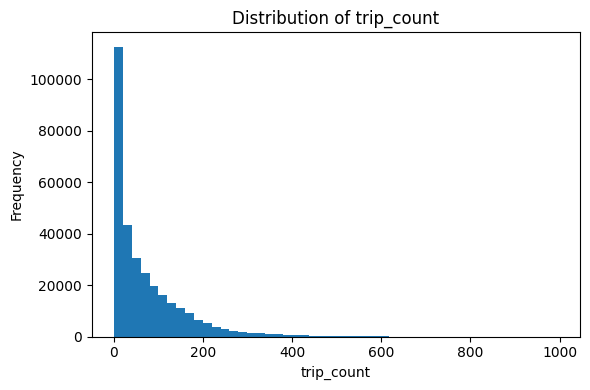

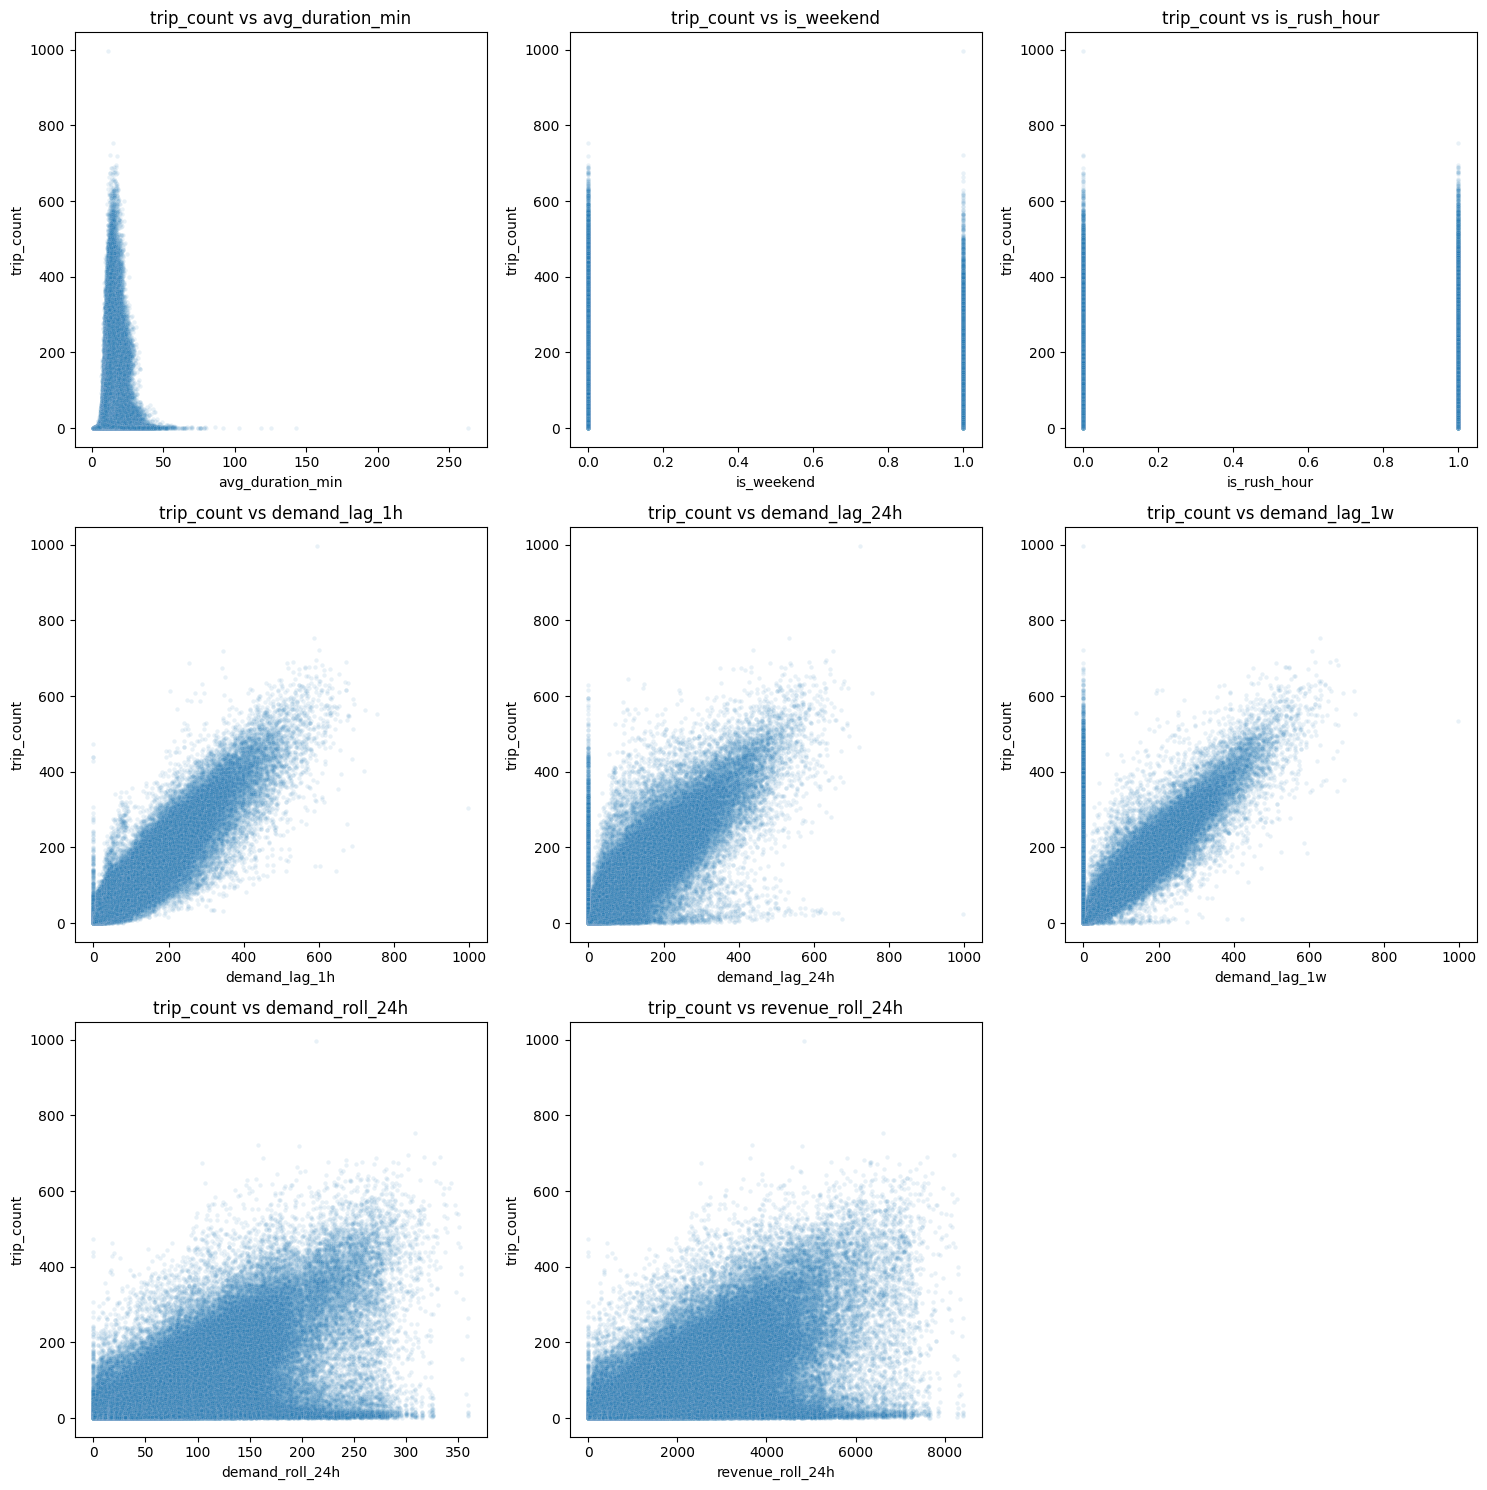

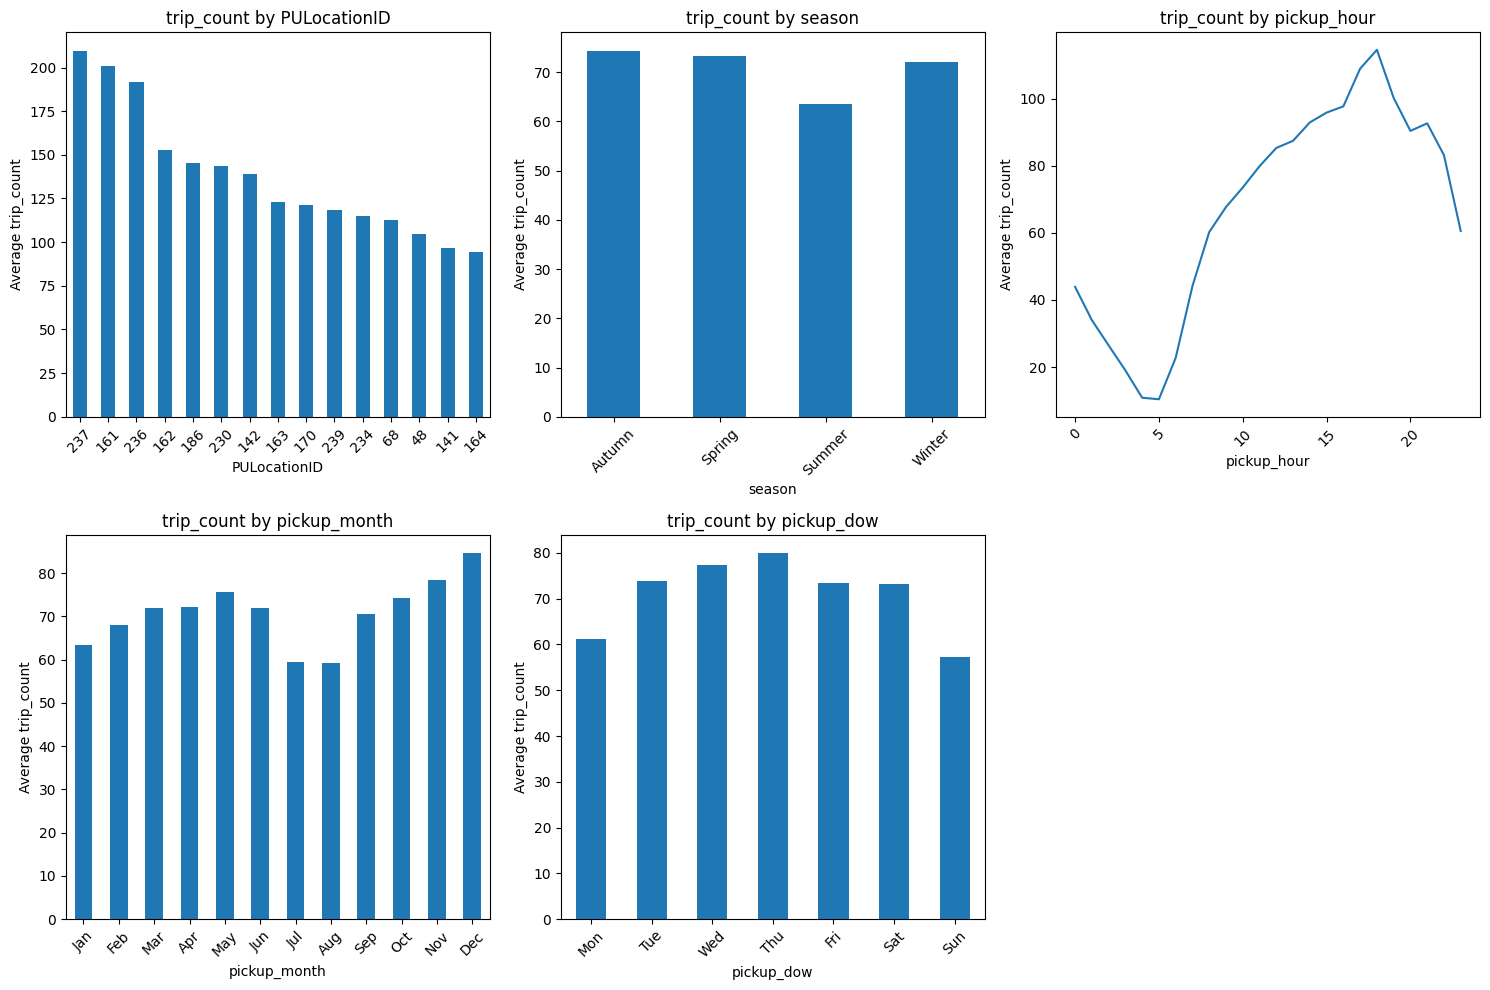

In [24]:
eda_target(taxi_clean, 'trip_count')

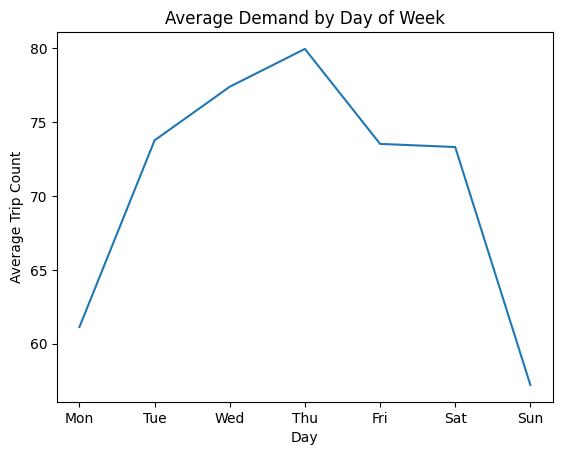

In [25]:
# plotting demand by day of week

# creating days of the week map for visualization
day_map = {
    0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu',
    4: 'Fri', 5: 'Sat', 6: 'Sun'
}

demand_by_day = taxi_clean.groupby('pickup_dow')['trip_count'].mean()

demand_by_day.index = demand_by_day.index.map(day_map)

demand_by_day.plot()

plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Trip Count")

plt.show()

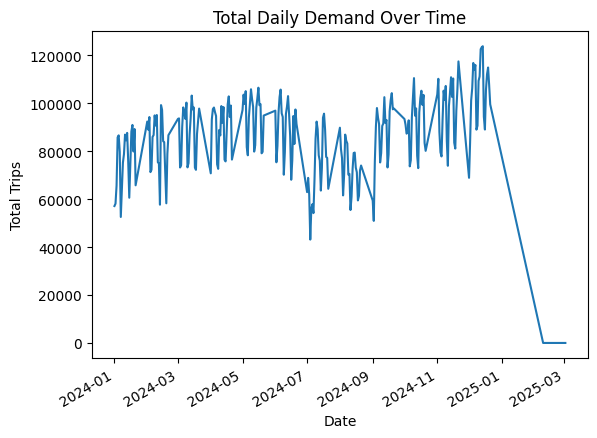

In [26]:
# plotting demand over time to check stability and trends

taxi_clean.groupby('pickup_date')['trip_count'].sum().plot()
plt.title("Total Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Trips")
plt.show()

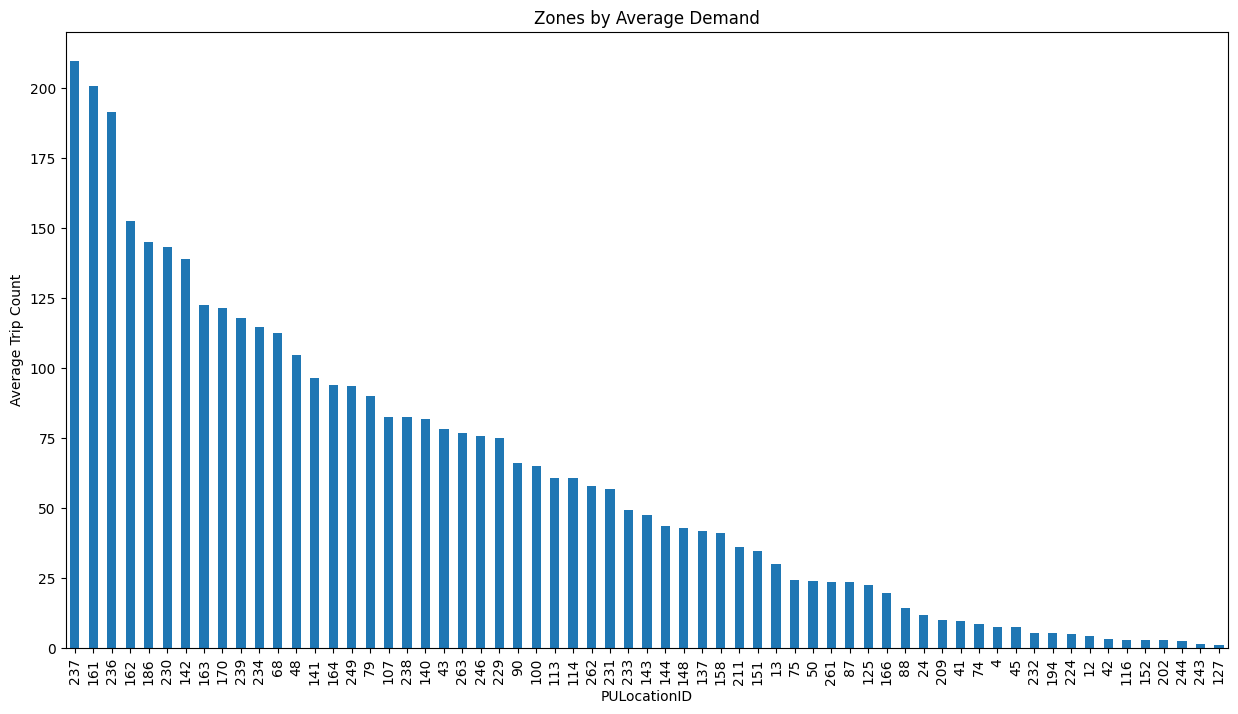

In [27]:
# plotting zone level demand differences

top_zones = taxi_clean.groupby('PULocationID')['trip_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 8))
top_zones.plot(kind='bar')
plt.title("Zones by Average Demand")
plt.ylabel("Average Trip Count")
plt.show()

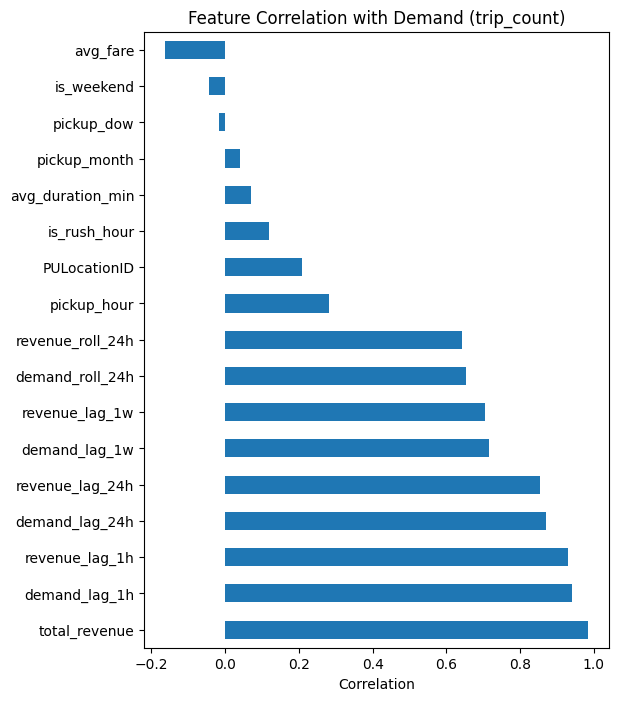

In [28]:
# checking correlation with target variable

corr = taxi_clean.corr(numeric_only=True)['trip_count'].sort_values(ascending=False)

plt.figure(figsize=(6,8))
corr.drop('trip_count').plot(kind='barh')
plt.title("Feature Correlation with Demand (trip_count)")
plt.xlabel("Correlation")
plt.show()

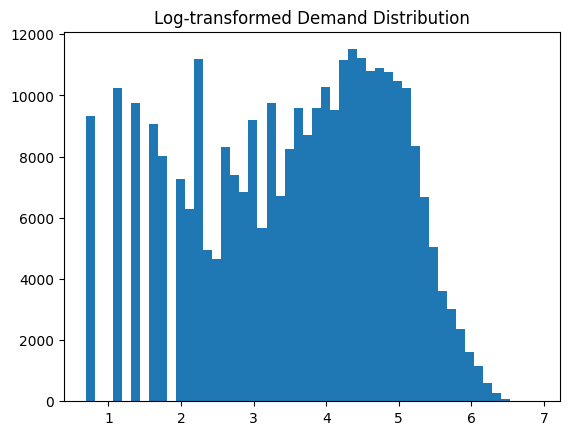

In [29]:
# checking if log transform is needed for demand based on the log distribution

plt.hist(np.log1p(taxi_clean['trip_count']), bins=50)
plt.title("Log-transformed Demand Distribution")
plt.show()

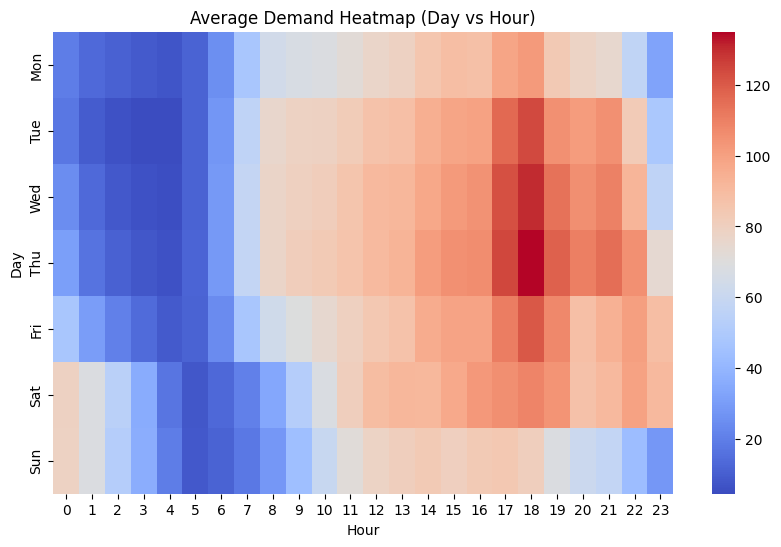

In [30]:
# plotting the average demand for days per hour

pivot_time = taxi_clean.pivot_table(
    values='trip_count',
    index='pickup_dow',
    columns='pickup_hour',
    aggfunc='mean'
)

# map numbers to days of the week
day_map = {
    0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu',
    4: 'Fri', 5: 'Sat', 6: 'Sun'
}

pivot_time.index = pivot_time.index.map(day_map)

pivot_time = pivot_time.reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

# plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(pivot_time.astype(float), cmap='coolwarm')

plt.title("Average Demand Heatmap (Day vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

In [31]:
# compare top vs bottom zones
zone_mean = taxi_clean.groupby('PULocationID')['trip_count'].mean()

top_zone = zone_mean.sort_values(ascending=False).head(5)
bottom_zone = zone_mean.sort_values().head(5)

print("Top zones:\n", top_zone)
print("\nLowest zones:\n", bottom_zone)

Top zones:
 PULocationID
237    209.662972
161    200.793986
236    191.614756
162    152.594056
186     145.13825
Name: trip_count, dtype: Float64

Lowest zones:
 PULocationID
127    1.142857
243    1.451613
244    2.690117
202         3.0
152    3.019539
Name: trip_count, dtype: Float64


#### Possible Suggestions for Feature Engineering (Demand Prediction)

- cyclical encoding of hour (helps the model to recognise that late night is close to early morning)
- interaction between hour and weekend (could maybe see demand patterns at the same hour depending on wether it is a week day or weekend)
- demand change between the lag features (could see trends by measuring how demand is increasing or decreasing)
- calculating ratios for lag (could help see spikes in the data)
- calculating averages (could help capuring underlying trends and reduce noise a bit)
